# **`-- IMPORTS --`**

In [23]:
from IPython.display import display, HTML

display(HTML('<style>.container {width:92% !important;}</style>'))
display(HTML('<style>div.output_scroll {height: 28em;}</style>'))
display(HTML('<style>.rendered_html {font-size: 15px;}</style>'))

In [14]:
import os
import pandas as pd
pd.set_option('display.max_colwidth', 350)
pd.set_option('display.width', None)
pd.options.display.max_rows = 65
pd.options.display.max_columns = None
pd.set_option('display.expand_frame_repr', False)

# import requests
# from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
# import seaborn as sns
# import time
# import json
# from bs4 import BeautifulSoup

# **`-- PICKS CSV --`**

In [100]:
df = pd.read_csv('Draft NBA Yahoo Fantasy 2025 - Picks.csv')
df.columns = df.columns.str.lower().str.replace(" ", "_")
df["pick"] = df["pick"].ffill()
df["pick_number"] = df["pick_number"].ffill()
df = df[df.pick < 10]
df

,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",NaN,68,0.469,0.770,235,1973,540,532,106,23,235
1,1.0,5.0,5,5,72,5.9,Giannis Antetokounmpo MIL,"PF,C",NaN,68,0.570,0.639,35,2161,784,469,70,70,293
2,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,NaN,75,0.524,0.719,33,1548,776,400,89,73,208
3,2.0,24.0,22,22,20,26.1,Jalen Johnson ATL,"SF,PF",GTD,69,0.500,0.744,96,1386,628,362,97,63,169
4,2.0,24.0,27,27,51,29.8,Josh Giddey CHI,"PG,SG",NaN,70,0.464,0.782,102,1201,570,617,78,47,261
5,2.0,24.0,24,24,9,26.6,Scottie Barnes TOR,"SG,SF,PF",GTD,71,0.456,0.770,106,1378,563,392,98,86,189
6,3.0,33.0,30,30,53,38.3,Jamal Murray DEN,"PG,SG",NaN,66,0.461,0.869,142,1279,251,381,76,22,142
7,3.0,33.0,33,33,24,35.3,Derrick White BOS,"PG,SG",NaN,74,0.425,0.840,238,1377,342,399,66,74,147
8,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
9,3.0,33.0,41,41,81,26.2,Paolo Banchero ORL,"PF,C",GTD,69,0.474,0.730,128,1750,493,328,63,47,188


In [101]:
df.position.value_counts()

position
PG,SG       11
PF,C        10
SF,PF        9
C            6
SG,SF,PF     2
SG,SF        2
PG,SG,SF     1
PG           1
Name: count, dtype: int64

In [102]:
df_temp = df['position'].str.split(',',expand=True)
df_temp.head()

,0,1,2
0,PG,SG,None
1,PF,C,None
2,C,None,None
3,SF,PF,None
4,PG,SG,None


In [103]:
d1 = df_temp[0].value_counts().to_dict()
d2 = df_temp[1].value_counts().to_dict()
d3 = df_temp[2].value_counts().to_dict()

In [104]:
result = {k: sum(d.get(k, 0) for d in [d1, d2, d3]) for k in set().union(d1, d2, d3)}
result

{'SG': 16, 'SF': 14, 'C': 16, 'PF': 21, 'PG': 13}

# **`-- TEAMS CSV --`**

## **Sample**

In [67]:
df = pd.read_csv('sample_top_teams_minmax.csv')
# df['player'] = df['player'].astype(str)
df

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
1,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,3.0,33.0,33,33,24,35.3,Derrick White BOS,"PG,SG",-,74,0.425,0.840,238,1377,342,399,66,74,147
3,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,4.0,52.0,44,44,61,50.5,Deni Avdija POR,"SF,PF",-,74,0.476,0.761,149,1388,556,332,88,43,225
4,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,5.0,61.0,56,56,115,70.6,Brandon Ingram TOR,"SG,SF,PF",GTD,63,0.475,0.843,108,1229,312,291,52,42,168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,100,100,0.495111,0.762778,1116.0,11748.0,4404.0,2791.0,625.0,450.0,0.400,0.800,17,2,4,3,4,4,5.0,61.0,56,56,115,70.6,Brandon Ingram TOR,"SG,SF,PF",GTD,63,0.475,0.843,108,1229,312,291,52,42,168
896,100,100,0.495111,0.762778,1116.0,11748.0,4404.0,2791.0,625.0,450.0,0.400,0.800,17,2,4,3,4,4,6.0,80.0,75,75,82,77.9,Jakob Poeltl TOR,C,GTD,68,0.633,0.639,0,875,634,177,63,95,118
897,100,100,0.495111,0.762778,1116.0,11748.0,4404.0,2791.0,625.0,450.0,0.400,0.800,17,2,4,3,4,4,7.0,89.0,90,90,134,93.8,Benedict Mathurin IND,"SG,SF",-,73,0.451,0.829,107,1302,364,169,55,24,153
898,100,100,0.495111,0.762778,1116.0,11748.0,4404.0,2791.0,625.0,450.0,0.400,0.800,17,2,4,3,4,4,8.0,108.0,100,100,77,107.0,Santi Aldama MEM,"PF,C",-,70,0.480,0.694,154,1059,508,264,61,45,90


In [68]:
df.team_id.nunique()

100

In [69]:
display(df[df.team_id == 1])
display(df[df.team_id == 2])

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
1,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,3.0,33.0,33,33,24,35.3,Derrick White BOS,"PG,SG",-,74,0.425,0.840,238,1377,342,399,66,74,147
3,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,4.0,52.0,44,44,61,50.5,Deni Avdija POR,"SF,PF",-,74,0.476,0.761,149,1388,556,332,88,43,225
4,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,5.0,61.0,56,56,115,70.6,Brandon Ingram TOR,"SG,SF,PF",GTD,63,0.475,0.843,108,1229,312,291,52,42,168
5,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,6.0,80.0,75,75,82,77.9,Jakob Poeltl TOR,C,GTD,68,0.633,0.639,0,875,634,177,63,95,118
6,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
7,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,8.0,108.0,108,108,66,117.8,Reed Sheppard HOU,"PG,SG",-,71,0.421,0.823,194,927,236,277,105,54,130
8,1,1,0.480556,0.765556,1213.0,11603.0,4533.0,2777.0,678.0,557.0,0.526,0.748,16,3,4,2,3,4,9.0,117.0,124,124,75,119.1,Bobby Portis MIL,"PF,C",-,70,0.478,0.793,119,1146,596,164,58,33,85


,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
9,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
10,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
11,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,3.0,33.0,33,33,24,35.3,Derrick White BOS,"PG,SG",-,74,0.425,0.840,238,1377,342,399,66,74,147
12,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,4.0,52.0,44,44,61,50.5,Deni Avdija POR,"SF,PF",-,74,0.476,0.761,149,1388,556,332,88,43,225
13,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,5.0,61.0,56,56,115,70.6,Brandon Ingram TOR,"SG,SF,PF",GTD,63,0.475,0.843,108,1229,312,291,52,42,168
14,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,6.0,80.0,75,75,82,77.9,Jakob Poeltl TOR,C,GTD,68,0.633,0.639,0,875,634,177,63,95,118
15,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
16,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,8.0,108.0,98,98,67,92.2,Naz Reid MIN,"PF,C",GTD,75,0.469,0.750,167,1107,454,186,62,83,124
17,2,2,0.485889,0.757444,1186.0,11783.0,4751.0,2686.0,635.0,586.0,0.515,1.166,16,2,3,2,4,5,9.0,117.0,124,124,75,119.1,Bobby Portis MIL,"PF,C",-,70,0.478,0.793,119,1146,596,164,58,33,85


## **Full**

In [127]:
df = pd.read_csv('top_teams_minmax.csv')
df['player'] = df['player'].astype(str)
df

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
1,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
3,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
4,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,5.0,61.0,63,63,37,60.4,Coby White CHI,"PG,SG",GTD,74,0.440,0.869,238,1586,302,352,63,17,176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699995,300000,300000,0.521333,0.738222,901.0,10357.0,4614.0,1974.0,813.0,635.0,1113.0,0.416,1.2,17,2,2,4,5,4,5.0,61.0,72,72,34,64.8,OG Anunoby NYK,"SF,PF",GTD,66,0.486,0.799,151,1168,315,140,110,58,94
2699996,300000,300000,0.521333,0.738222,901.0,10357.0,4614.0,1974.0,813.0,635.0,1113.0,0.416,1.2,17,2,2,4,5,4,6.0,80.0,75,75,82,77.9,Jakob Poeltl TOR,C,GTD,68,0.633,0.639,0,875,634,177,63,95,118
2699997,300000,300000,0.521333,0.738222,901.0,10357.0,4614.0,1974.0,813.0,635.0,1113.0,0.416,1.2,17,2,2,4,5,4,7.0,89.0,99,99,41,85.1,Kel'el Ware MIA,"PF,C",-,70,0.559,0.711,59,951,673,96,58,106,77
2699998,300000,300000,0.521333,0.738222,901.0,10357.0,4614.0,1974.0,813.0,635.0,1113.0,0.416,1.2,17,2,2,4,5,4,8.0,108.0,97,97,45,93.0,Onyeka Okongwu ATL,C,GTD,69,0.580,0.779,56,981,578,144,62,83,92


In [128]:
team_cols = [col for col in df.columns if col.startswith('team_')]
pos_cols = [col for col in df.columns if col.startswith('pos_')]
cols = team_cols + pos_cols + ['distinct_positions']
df_teams = df.drop_duplicates(subset='team_id')[cols]
df_teams

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,distinct_positions
0,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.800,4,4,2,3,4,17
9,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,4,3,2,3,4,16
18,3,3,0.457000,0.765667,1479.0,12777.0,4223.0,2932.0,802.0,417.0,1591.0,0.611,1.356,5,5,2,2,3,17
27,4,4,0.462333,0.759556,1504.0,12807.0,4409.0,2789.0,777.0,437.0,1465.0,0.611,0.800,4,4,2,3,4,17
36,5,5,0.458333,0.761333,1501.0,12484.0,4251.0,2933.0,819.0,414.0,1545.0,0.610,1.166,5,4,2,2,3,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699955,299996,299996,0.472778,0.787000,1166.0,12462.0,4107.0,2765.0,531.0,398.0,1500.0,0.416,1.020,2,5,3,4,4,18
2699964,299997,299997,0.478444,0.801111,1362.0,11697.0,3912.0,2477.0,661.0,417.0,1363.0,0.416,0.800,3,4,3,5,3,18
2699973,299998,299998,0.489222,0.789889,1153.0,12851.0,4000.0,2756.0,581.0,320.0,1474.0,0.416,0.800,2,4,3,4,4,17
2699982,299999,299999,0.493111,0.766667,1107.0,11147.0,3965.0,2638.0,720.0,459.0,1317.0,0.416,0.400,3,3,3,4,3,16


In [129]:
df[['player', 'pos_sg_count']]

,player,pos_sg_count
0,Luka Doncic DAL,4
1,Alperen Sengun HOU,4
2,Dyson Daniels ATL,4
3,Brandon Miller CHA,4
4,Coby White CHI,4
...,...,...
2699995,OG Anunoby NYK,2
2699996,Jakob Poeltl TOR,2
2699997,Kel'el Ware MIA,2
2699998,Onyeka Okongwu ATL,2


In [130]:
df.head()

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
1,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
3,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
4,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,5.0,61.0,63,63,37,60.4,Coby White CHI,"PG,SG",GTD,74,0.440,0.869,238,1586,302,352,63,17,176


In [131]:
display(df[df.team_id == 1])
display(df[df.team_id == 2])

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
1,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
3,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
4,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,5.0,61.0,63,63,37,60.4,Coby White CHI,"PG,SG",GTD,74,0.440,0.869,238,1586,302,352,63,17,176
5,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,6.0,80.0,78,78,98,72.5,Jalen Green PHX,"PG,SG",O,78,0.425,0.809,232,1723,382,294,64,22,220
6,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
7,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,8.0,108.0,98,98,67,92.2,Naz Reid MIN,"PF,C",GTD,75,0.469,0.750,167,1107,454,186,62,83,124
8,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,9.0,117.0,124,124,75,119.1,Bobby Portis MIL,"PF,C",-,70,0.478,0.793,119,1146,596,164,58,33,85


,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
9,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
10,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
11,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
12,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
13,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,5.0,61.0,68,68,30,69.3,Payton Pritchard BOS,PG,-,76,0.452,0.830,260,1293,330,353,80,14,130
14,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,6.0,80.0,78,78,98,72.5,Jalen Green PHX,"PG,SG",O,78,0.425,0.809,232,1723,382,294,64,22,220
15,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
16,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,8.0,108.0,98,98,67,92.2,Naz Reid MIN,"PF,C",GTD,75,0.469,0.750,167,1107,454,186,62,83,124
17,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,9.0,117.0,124,124,75,119.1,Bobby Portis MIL,"PF,C",-,70,0.478,0.793,119,1146,596,164,58,33,85


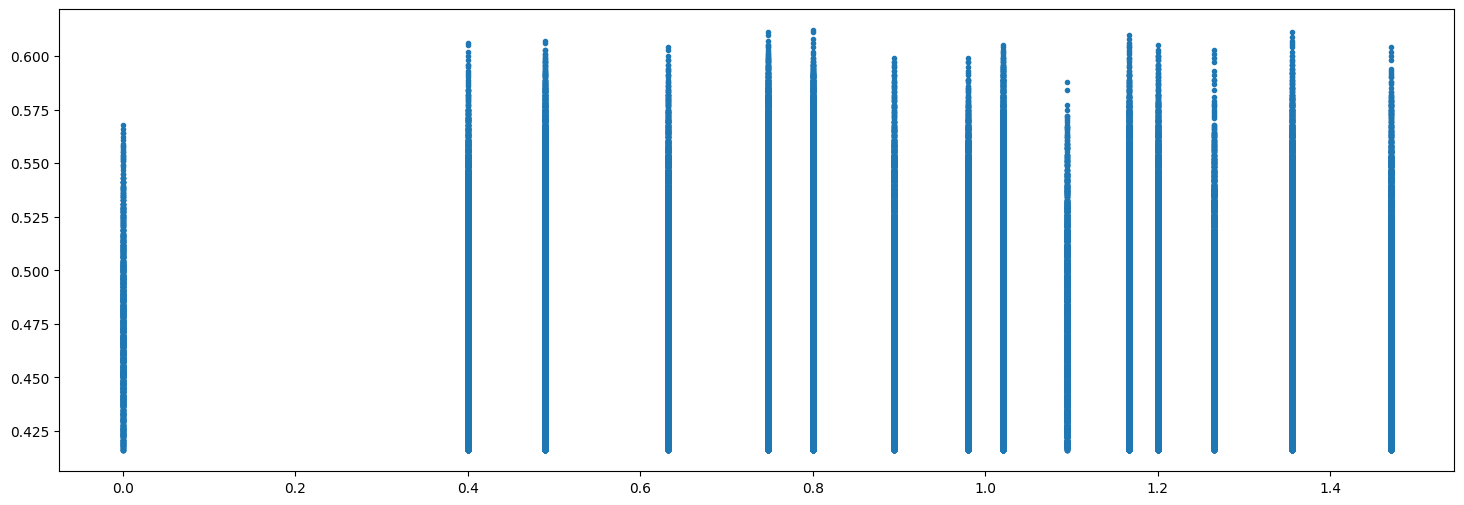

In [132]:
plt.figure(figsize=(18, 6))
plt.plot(df_teams.pos_std, df_teams.team_cs, '.')
plt.show()

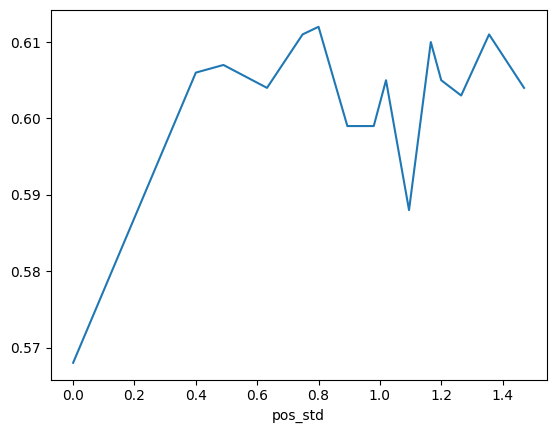

In [133]:
df_teams.groupby('pos_std')['team_cs'].max().plot()
plt.show()

In [134]:
df.team_id.nunique()

300000

In [135]:
df[df.pick == 1]['player'].value_counts()

player
Luka Doncic DAL              171967
Giannis Antetokounmpo MIL    128033
Name: count, dtype: int64

In [136]:
df[df.pick == 2]['player'].value_counts()

player
Alperen Sengun HOU    86421
Josh Giddey CHI       77724
Jalen Johnson ATL     68927
Scottie Barnes TOR    66928
Name: count, dtype: int64

In [137]:
df[df.pick == 3]['player'].value_counts()

player
Dyson Daniels ATL     80744
Derrick White BOS     68715
Austin Reaves LAL     57883
Jamal Murray DEN      49121
Paolo Banchero ORL    43537
Name: count, dtype: int64

In [138]:
df[df.pick == 4]['player'].value_counts()

player
Nikola Vucevic CHI        57499
Brandon Miller CHA        57170
Deni Avdija POR           56820
Myles Turner MIL          54659
Kawhi Leonard LAC         44568
Kristaps Porzingis ATL    29284
Name: count, dtype: int64

In [139]:
df[df.pick == 4]['player'].value_counts()

player
Nikola Vucevic CHI        57499
Brandon Miller CHA        57170
Deni Avdija POR           56820
Myles Turner MIL          54659
Kawhi Leonard LAC         44568
Kristaps Porzingis ATL    29284
Name: count, dtype: int64

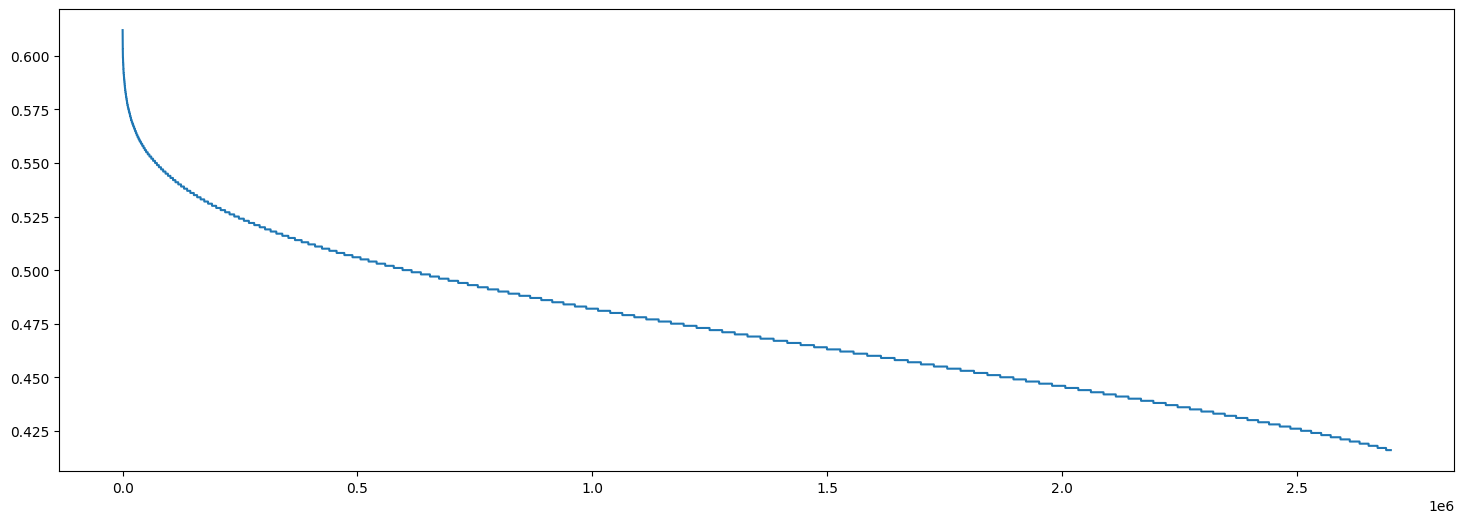

In [140]:
df.drop_duplicates(subset='team_id')['team_cs'].plot(figsize=(18, 6))
plt.show()

In [141]:
df[df.team_rank == 1]

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
1,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
3,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
4,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,5.0,61.0,63,63,37,60.4,Coby White CHI,"PG,SG",GTD,74,0.440,0.869,238,1586,302,352,63,17,176
5,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,6.0,80.0,78,78,98,72.5,Jalen Green PHX,"PG,SG",O,78,0.425,0.809,232,1723,382,294,64,22,220
6,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
7,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,8.0,108.0,98,98,67,92.2,Naz Reid MIN,"PF,C",GTD,75,0.469,0.750,167,1107,454,186,62,83,124
8,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,9.0,117.0,124,124,75,119.1,Bobby Portis MIL,"PF,C",-,70,0.478,0.793,119,1146,596,164,58,33,85


In [142]:
df[df.team_rank == 2]

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
9,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
10,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
11,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
12,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
13,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,5.0,61.0,68,68,30,69.3,Payton Pritchard BOS,PG,-,76,0.452,0.830,260,1293,330,353,80,14,130
14,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,6.0,80.0,78,78,98,72.5,Jalen Green PHX,"PG,SG",O,78,0.425,0.809,232,1723,382,294,64,22,220
15,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
16,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,8.0,108.0,98,98,67,92.2,Naz Reid MIN,"PF,C",GTD,75,0.469,0.750,167,1107,454,186,62,83,124
17,2,2,0.462444,0.761444,1539.0,12562.0,4383.0,2712.0,795.0,472.0,1453.0,0.611,0.748,16,4,3,2,3,4,9.0,117.0,124,124,75,119.1,Bobby Portis MIL,"PF,C",-,70,0.478,0.793,119,1146,596,164,58,33,85


In [143]:
df[df.pos_std == df.pos_std.min()]

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
21393,2378,2378,0.468889,0.786111,1485.0,12181.0,4280.0,2630.0,688.0,604.0,1392.0,0.568,0.0,15,3,3,3,3,3,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
21394,2378,2378,0.468889,0.786111,1485.0,12181.0,4280.0,2630.0,688.0,604.0,1392.0,0.568,0.0,15,3,3,3,3,3,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
21395,2378,2378,0.468889,0.786111,1485.0,12181.0,4280.0,2630.0,688.0,604.0,1392.0,0.568,0.0,15,3,3,3,3,3,3.0,33.0,33,33,24,35.3,Derrick White BOS,"PG,SG",-,74,0.425,0.840,238,1377,342,399,66,74,147
21396,2378,2378,0.468889,0.786111,1485.0,12181.0,4280.0,2630.0,688.0,604.0,1392.0,0.568,0.0,15,3,3,3,3,3,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
21397,2378,2378,0.468889,0.786111,1485.0,12181.0,4280.0,2630.0,688.0,604.0,1392.0,0.568,0.0,15,3,3,3,3,3,5.0,61.0,63,63,37,60.4,Coby White CHI,"PG,SG",GTD,74,0.440,0.869,238,1586,302,352,63,17,176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2696818,299647,299647,0.495333,0.804111,1256.0,11922.0,4066.0,2504.0,663.0,380.0,1330.0,0.416,0.0,15,3,3,3,3,3,5.0,61.0,68,68,30,69.3,Payton Pritchard BOS,PG,-,76,0.452,0.830,260,1293,330,353,80,14,130
2696819,299647,299647,0.495333,0.804111,1256.0,11922.0,4066.0,2504.0,663.0,380.0,1330.0,0.416,0.0,15,3,3,3,3,3,6.0,80.0,88,88,117,82.3,Cam Thomas BKN,"SG,SF",-,65,0.427,0.861,176,1487,242,282,44,14,161
2696820,299647,299647,0.495333,0.804111,1256.0,11922.0,4066.0,2504.0,663.0,380.0,1330.0,0.416,0.0,15,3,3,3,3,3,7.0,89.0,93,93,106,92.4,John Collins LAC,"PF,C",-,66,0.529,0.812,84,1003,498,96,48,64,115
2696821,299647,299647,0.495333,0.804111,1256.0,11922.0,4066.0,2504.0,663.0,380.0,1330.0,0.416,0.0,15,3,3,3,3,3,8.0,108.0,97,97,45,93.0,Onyeka Okongwu ATL,C,GTD,69,0.580,0.779,56,981,578,144,62,83,92


In [147]:
df[df.team_id == df.groupby('team_id')['xrank'].mean().sort_values().index[0]]

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
2477700,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
2477701,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2477702,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,3.0,33.0,30,30,53,38.3,Jamal Murray DEN,"PG,SG",-,66,0.461,0.869,142,1279,251,381,76,22,142
2477703,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,4.0,52.0,44,44,61,50.5,Deni Avdija POR,"SF,PF",-,74,0.476,0.761,149,1388,556,332,88,43,225
2477704,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,5.0,61.0,56,56,115,70.6,Brandon Ingram TOR,"SG,SF,PF",GTD,63,0.475,0.843,108,1229,312,291,52,42,168
2477705,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,6.0,80.0,75,75,82,77.9,Jakob Poeltl TOR,C,GTD,68,0.633,0.639,0,875,634,177,63,95,118
2477706,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,7.0,89.0,90,90,134,93.8,Benedict Mathurin IND,"SG,SF",-,73,0.451,0.829,107,1302,364,169,55,24,153
2477707,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,8.0,108.0,97,97,45,93.0,Onyeka Okongwu ATL,C,GTD,69,0.580,0.779,56,981,578,144,62,83,92
2477708,275301,275301,0.504333,0.772111,957.0,11413.0,4425.0,2578.0,700.0,451.0,1428.0,0.427,0.748,16,2,4,4,3,3,9.0,117.0,120,120,73,107.6,Toumani Camara POR,"SF,PF",GTD,75,0.470,0.740,127,838,414,152,109,46,87


In [148]:
df[df.team_id == df.groupby('team_id')['adp'].mean().sort_values().index[0]]

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
69066,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
69067,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
69068,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,3.0,33.0,41,41,81,26.2,Paolo Banchero ORL,"PF,C",GTD,69,0.474,0.730,128,1750,493,328,63,47,188
69069,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,4.0,52.0,46,46,44,46.4,Kawhi Leonard LAC,"SF,PF",-,55,0.510,0.858,125,1300,362,207,86,22,121
69070,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,5.0,61.0,63,63,37,60.4,Coby White CHI,"PG,SG",GTD,74,0.440,0.869,238,1586,302,352,63,17,176
69071,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,6.0,80.0,78,78,98,72.5,Jalen Green PHX,"PG,SG",O,78,0.425,0.809,232,1723,382,294,64,22,220
69072,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
69073,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,8.0,108.0,98,98,67,92.2,Naz Reid MIN,"PF,C",GTD,75,0.469,0.750,167,1107,454,186,62,83,124
69074,7675,7675,0.467222,0.771889,1422.0,12965.0,4264.0,2656.0,693.0,453.0,1478.0,0.55,0.748,16,3,3,2,4,4,9.0,117.0,120,120,73,107.6,Toumani Camara POR,"SF,PF",GTD,75,0.470,0.740,127,838,414,152,109,46,87


In [149]:
df[df.team_rank == 1]

,team_id,team_rank,team_fg%,team_ft%,team_3ptm,team_pts,team_reb,team_ast,team_st,team_blk,team_to,team_cs,pos_std,distinct_positions,pos_pg_count,pos_sg_count,pos_sf_count,pos_pf_count,pos_c_count,pick,pick_number,selected_xrank,xrank,rank,adp,player,position,status,gp,fg%,ft%,3ptm,pts,reb,ast,st,blk,to
0,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,1.0,5.0,3,3,6,5.2,Luka Doncic DAL,"PG,SG",-,68,0.469,0.770,235,1973,540,532,106,23,235
1,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,2.0,24.0,21,21,28,19.6,Alperen Sengun HOU,C,-,75,0.524,0.719,33,1548,776,400,89,73,208
2,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,3.0,33.0,42,42,13,37.0,Dyson Daniels ATL,"PG,SG,SF",GTD,70,0.496,0.633,81,1024,416,312,196,53,139
3,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,4.0,52.0,49,49,29,51.5,Brandon Miller CHA,"SF,PF",-,70,0.425,0.847,275,1608,348,266,89,51,193
4,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,5.0,61.0,63,63,37,60.4,Coby White CHI,"PG,SG",GTD,74,0.440,0.869,238,1586,302,352,63,17,176
5,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,6.0,80.0,78,78,98,72.5,Jalen Green PHX,"PG,SG",O,78,0.425,0.809,232,1723,382,294,64,22,220
6,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,7.0,89.0,95,95,95,82.9,Alex Sarr WAS,C,GTD,70,0.424,0.702,137,1140,541,205,51,120,119
7,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,8.0,108.0,98,98,67,92.2,Naz Reid MIN,"PF,C",GTD,75,0.469,0.750,167,1107,454,186,62,83,124
8,1,1,0.461111,0.765778,1517.0,12855.0,4355.0,2711.0,778.0,475.0,1499.0,0.612,0.8,17,4,4,2,3,4,9.0,117.0,124,124,75,119.1,Bobby Portis MIL,"PF,C",-,70,0.478,0.793,119,1146,596,164,58,33,85
